---
### New Package
---

In this block, we load a new package, [cvxopt](https://cvxopt.org/), which will allow us to perform constrained optimization to solve the SVM problem. If needed, install it first with `pip install cvxopt`.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers

---
### 1. Maximum Margin Classifier
---
Throughout, we will use the <font color="#508FE2"><tt>solvers.qp</tt></font> method which can be used to solve the quadratic program
<font color="#75B05A">
$$
\begin{aligned}
&\min_{\alpha\in\mathbb R^n}\frac{1}{2}\alpha^{\intercal}Q\alpha+p^{\intercal}\alpha
\\
&\text{subject to }G \alpha\leq h
\end{aligned}
$$
</font>
using the call  <font color="#508FE2"><tt>solvers.qp(Q, p, G, h)</tt></font>, where <font color="#508FE2">Q,p,G,h</font> should be numpy arrays converted into cvxopt matrices (see the following block).


Note that a formulation for maximum margin classifier can be written as
<font color="#75B05A">
$$
\begin{aligned}
&\min_{(w,b) \in\mathbb R^d\times \mathbb R}\frac{1}{2}w^Tw
\\
\text{subject to }& y^{(i)}(w^Tx^{(i)}+b) \geq 1
\end{aligned}
$$
</font>


The following block implements the function which takes $X,y$ and returns the optimal $w,b$.
### <font color='#7EA8BE'> **Problem 1 a)**</font>

In the marked section, define matrices and vectors $Q,p,G,h$ appropriate for the MMC optimization above.
### <font color='#7EA8BE'> **Problem 1 b)**</font>

Using the matrices above, solve the MMC problem and return optimal $w$ and $b$.

In [ ]:
def MMCSolver(X, y):
  n, d = X.shape

  # Problem 1 a)
  # ====== Add your code here ======

    # Q matrix
  Q = np.zeros((d + 1, d + 1))
  Q[:d, :d] = np.eye(d)

    # p vector
  p = np.zeros(d + 1)

    # G matrix
  G = np.zeros((n, d + 1))
  for i in range(n):
    G[i, :d] = -y[i] * X[i]
    G[i, d] = -y[i]

    # h vector
  h = -np.ones(n)

    # Convert to cvxopt format
  Q = matrix(Q)
  p = matrix(p)
  G = matrix(G)
  h = matrix(h)
 # ======        End         ======
  # Problem 1 b)
  # ====== Add your code here ======

  solution = solvers.qp(Q, p, G, h)
  alpha = np.array(solution['x']).flatten()

  w = alpha[:d]
  b = alpha[d]
  # ======        End         ======
  return w, b

In the following block, we provide a dataset which is linearly separable.


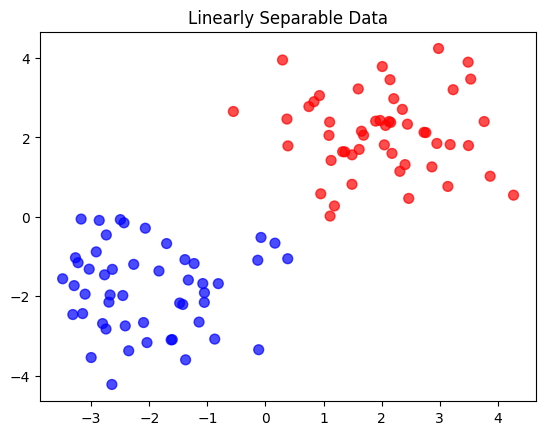

In [ ]:
np.random.seed(0)

# Generate two separable classes
n_samples = 50
X_pos = np.random.randn(n_samples, 2) + np.array([2, 2])
X_neg = np.random.randn(n_samples, 2) + np.array([-2, -2])

X = np.vstack([X_pos, X_neg])
y = np.array([1]*n_samples + [-1]*n_samples)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=50, alpha=0.7)
plt.title('Linearly Separable Data')
plt.show()



### <font color='#7EA8BE'> **Problem 1 c)**</font>

Use <font color="#508FE2"><tt>MMCSolver</tt></font>, the design matrix <font color="#508FE2"><tt>X</tt></font>, and the vector of labels <font color="#508FE2"><tt>y</tt></font> to find a classifier that perfectly classifies this dataset. Print $w$ and $b$. Calculate the margin. Plot the decision boundary and the margins.

     pcost       dcost       gap    pres   dres
 0:  4.9548e-02  2.9852e+01  3e+02  2e+00  5e+02
 1:  3.6071e-01 -4.6080e+01  8e+01  5e-01  1e+02
 2:  6.4621e-01 -3.9520e+01  8e+01  5e-01  1e+02
 3:  1.2465e+00 -3.6887e+01  5e+01  2e-01  5e+01
 4:  1.7015e+00 -6.7841e-01  2e+00  6e-03  2e+00
 5:  1.4673e+00  1.3824e+00  9e-02  1e-04  3e-02
 6:  1.4635e+00  1.4624e+00  1e-03  1e-06  3e-04
 7:  1.4635e+00  1.4635e+00  1e-05  1e-08  3e-06
 8:  1.4635e+00  1.4635e+00  1e-07  1e-10  3e-08
Optimal solution found.
Optimal w: [1.38881053 0.99908208]
Optimal b: -0.563840772363877


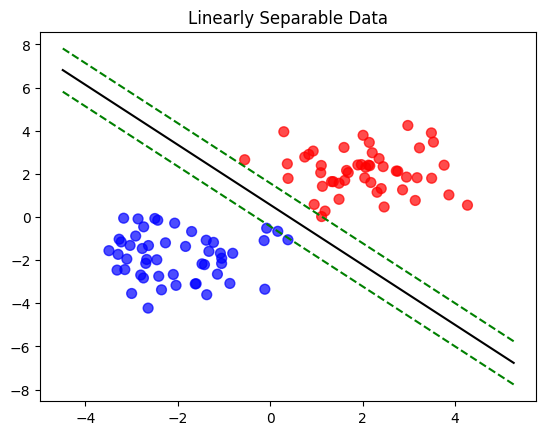

In [ ]:
# Problem 1 c)
w,b = MMCSolver(X,y)
print("Optimal w:", w)
print("Optimal b:", b)
# Decision boundary
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
x_plot = np.linspace(x_min, x_max, 100)

# ====== Add your code here ======
# Replace y_plot, y_upper, and y_lower with the appropriate line functions

# Decision boundary
y_plot = -(w[0]*x_plot + b) / w[1]
# Margins
y_upper = -(w[0]*x_plot + b - 1) / w[1]
y_lower = -(w[0]*x_plot + b + 1) / w[1]

# ======        End         ======

# Margin
# ====== Add your code here ======
# Replace margin with the appropriate margin formula
margin = 1  # Replace this
# ======        End         ======

plt.plot(x_plot, y_plot, 'k', label='Decision boundary')
plt.plot(x_plot, y_upper, 'g--', label='Margins')
plt.plot(x_plot, y_lower, 'g--')
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=50, alpha=0.7)
plt.title('Linearly Separable Data')
plt.show()


### <font color='#7EA8BE'> **Problem 1 d)**</font>

From <font color="#508FE2"><tt>sklearn.svm</tt></font>, use function <font color="#508FE2"><tt>SVC</tt></font>, and parameters <font color="#508FE2"><tt>kernel='linear', C=1e10</tt></font>, and fit data <font color="#508FE2"><tt>X,y</tt></font>. Compare the results of this algorithm with your QP solver. They should be close. You can use <font color="#508FE2"><tt>.coef_</tt></font> and <font color="#508FE2"><tt>.intercept_</tt></font> to access w and b respectively.

In [ ]:
from sklearn.svm import SVC
svc = SVC(kernel='linear', C=1e10)
# ====== Add your code here ======

svc.fit(X, y)

w_svc = svc.coef_.flatten()
b_svc = svc.intercept_[0]

print("SVC w:", w_svc)
print("SVC b:", b_svc)

# ======        End         ======



SVC w: [1.38881063 0.99908196]
SVC b: -0.5638408814905141


### <font color='#7EA8BE'> **Problem 1 e)**</font>

Consider the hard-margin SVM dual problem
$$
\begin{aligned}
&\max_{\alpha\in\mathbb R^n}\; \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i,j=1}^n \alpha_i\alpha_j y^{(i)}y^{(j)} (x^{(i)})^\top x^{(j)}
\\
&\text{subject to } \alpha_i \geq 0, \qquad \sum_{i=1}^n \alpha_i y^{(i)} = 0.
\end{aligned}
$$
Implement a dual solver using <font color="#508FE2"><tt>solvers.qp</tt></font>. Then recover the primal parameters using $w = \sum_{i=1}^n \alpha_i y^{(i)} x^{(i)}$ and compute $b$ using any support vector.


In [ ]:
# Problem 1 e)
def MMCDualSolver(X, y):
  n, d = X.shape
  # ====== Add your code here ======
  # Build the dual QP

  K = X @ X.T
  Q = np.outer(y, y) * K
  p = -np.ones(n)
  G = -np.eye(n)
  h = np.zeros(n)

    # Equality constraint: sum alpha_i y_i = 0
  A = y.reshape(1, -1).astype(float)
  b_eq = np.array([0.0])

  # Equality constraint: sum alpha_i y_i = 0
  A = y.reshape(1, -1).astype(float)
  b_eq = np.array([0.0])

  # Convert to cvxopt
  Q = matrix(Q)
  p = matrix(p)
  G = matrix(G)
  h = matrix(h)
  A = matrix(A)
  b_eq = matrix(b_eq)

  solution = solvers.qp(Q, p, G, h, A, b_eq)
  alpha = np.array(solution['x']).flatten()

  w = np.sum((alpha * y)[:, None] * X, axis=0)

    # Find support vectors (alpha > small threshold)
  sv = alpha > 1e-5

    # Compute b using any support vector
  b = np.mean(y[sv] - X[sv] @ w)
  # ======        End         ======

  return alpha, w, b

### <font color='#7EA8BE'> **Problem 1 f)**</font>

Use <font color="#508FE2"><tt>MMCDualSolver</tt></font> on the same dataset. Identify the support vectors using the dual variables (for example, by thresholding $\alpha_i$ at a small tolerance). Verify numerically that the support vectors satisfy the margin condition $y^{(i)}(w^T x^{(i)} + b) \approx 1$. Plot the dataset, the decision boundary, the margins, and highlight the support vectors. Compare your support vectors with those returned by <font color="#508FE2"><tt>sklearn.svm.SVC</tt></font>.


     pcost       dcost       gap    pres   dres
 0: -1.1400e+01 -2.1330e+01  3e+02  2e+01  2e+00
 1: -1.9261e+01 -1.1116e+01  8e+01  5e+00  5e-01
 2: -5.0870e+01 -2.5082e+01  8e+01  4e+00  5e-01
 3: -2.2869e+01 -6.1074e+00  5e+01  2e+00  2e-01
 4: -1.5953e+00 -1.7224e+00  2e+00  5e-02  6e-03
 5: -1.4212e+00 -1.4677e+00  9e-02  1e-03  1e-04
 6: -1.4628e+00 -1.4635e+00  1e-03  1e-05  1e-06
 7: -1.4635e+00 -1.4635e+00  1e-05  1e-07  1e-08
 8: -1.4635e+00 -1.4635e+00  1e-07  1e-09  1e-10
Optimal solution found.
Support vector indices: [16 99]
Margin values on support vectors: [1. 1.]


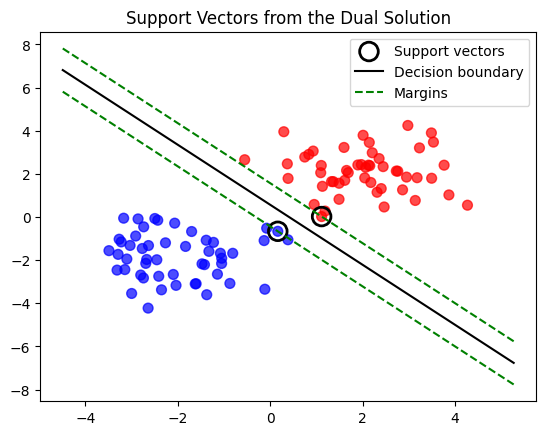

In [ ]:
# Problem 1 f)
alpha, w_dual, b_dual = MMCDualSolver(X, y)

# ====== Add your code here ======
# Identify the support vectors and verify the margin condition
tol = 1e-5
support_mask = alpha > tol
support_indices = np.where(support_mask)[0]
support_vectors = X[support_indices]
margin_values = y[support_indices] * (X[support_indices] @ w_dual + b_dual)

# Plot the decision boundary and margins
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
x_plot = np.linspace(x_min, x_max, 100)

y_plot = -(w_dual[0]*x_plot + b_dual) / w_dual[1]
y_upper = -(w_dual[0]*x_plot + b_dual - 1) / w_dual[1]
y_lower = -(w_dual[0]*x_plot + b_dual + 1) / w_dual[1]
# ======        End         ======

print("Support vector indices:", support_indices)
print("Margin values on support vectors:", margin_values)

plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=50, alpha=0.7)
plt.scatter(
    support_vectors[:,0],
    support_vectors[:,1],
    s=180,
    facecolors='none',
    edgecolors='k',
    linewidths=2,
    label='Support vectors'
)
plt.plot(x_plot, y_plot, 'k', label='Decision boundary')
plt.plot(x_plot, y_upper, 'g--', label='Margins')
plt.plot(x_plot, y_lower, 'g--')
plt.legend()
plt.title('Support Vectors from the Dual Solution')
plt.show()
